In [71]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime
from scipy.stats import norm
from scipy.optimize import brentq, minimize

## 1. Load Market Data

Historical VIX levels, SPX data, and the risk-free rate are loaded and prepared for model calibration and simulation inputs.

In [72]:
# Download historical VIX data
vix = pd.read_csv("data/raw/VIXCLS.csv")

In [73]:
# Load SPX data
spx = pd.read_csv("data/raw/spx.csv")

# Rename columns to match expected format
spx.rename(columns={'Price': 'Close'}, inplace=True)

# Convert 'Date' to datetime
spx['Date'] = pd.to_datetime(spx['Date'])

In [74]:
# Load the raw data
rates = pd.read_csv("data/raw/TB3MS.csv")

# Drop any rows with missing values
rates.dropna(inplace=True)

# Convert DATE to datetime
rates['observation_date'] = pd.to_datetime(rates['observation_date'])

# Sort by date and extract latest rate
rates.sort_values('observation_date', inplace=True)
latest_rate = rates.iloc[-1]['TB3MS'] / 100  # Convert from % to decimal
latest_rate

np.float64(0.042300000000000004)

## 2. Simulation Inputs

Define the valuation date, maturity, spot VIX level, risk-free rate, and initial Ornstein–Uhlenbeck parameters used in the Monte Carlo simulation.

In [99]:
# Simulation configuration
valuation_date = datetime(2025, 7, 24)  # assumed current date
expiry_date = datetime(2025, 7, 30)
days_to_expiry = (expiry_date - valuation_date).days
T = days_to_expiry / 365  # time to maturity in years

# Spot VIX and interest rate from earlier data uploaded
spot_vix = 13.83  # from VIXCLS.csv
r = 0.053  # from TB3MS.csv (5.3%)

kappa = 2.0
theta = 0.25
sigma = 0.5

# Option data
strikes = [9.68, 10.6, 11.52, 12.45, 13.37, 14.29, 15.21, 16.13, 17.06, 17.98]
mid_prices = [4.335, 3.8449999999999998, 2.91, 2.11, 1.495, 1.095]

# Build simulation inputs dictionary
simulation_inputs = {
    "valuation_date": valuation_date.strftime("%Y-%m-%d"),
    "expiry_date": expiry_date.strftime("%Y-%m-%d"),
    "time_to_maturity": T,
    "spot_vix": spot_vix,
    "risk_free_rate": r,
    "kappa": kappa,
    "theta": theta,
    "sigma": sigma,
    "strikes": strikes,
    "mid_prices": mid_prices,
    "num_paths": 10000,
    "num_steps": 252,
    "model": "OU"  # Ornstein-Uhlenbeck by default
}

with open("simulation_inputs.json", "w") as f:
    json.dump(simulation_inputs, f, indent=4)
    
print("Saved: simulation_inputs.json")

Saved: simulation_inputs.json


In [100]:
# Load simulation inputs
with open("simulation_inputs.json", "r") as f:
    inputs = json.load(f)

## 3. Options Chain Processing

Load the cleaned VIX options dataset, compute mid prices from bid–ask quotes, and filter the options for the target expiration used in the model.

In [97]:
# Load the CSV without header and assign column names manually
options_raw = pd.read_csv('data/processed/Cleaned_VIX_Options_Data.csv', header=None)

# Define the column names manually
columns = [
    'Expiration Date', 'Call Symbol', 'Last Sale', 'Net', 'Bid', 'Ask', 'Volume',
    'IV', 'Delta', 'Gamma', 'Put Symbol', 'Last Sale Put', 'Net Put', 'Bid Put',
    'Ask Put', 'Volume Put', 'IV Put', 'Delta Put', 'Gamma Put', 'Open Interest',
    'Strike'
]
options_raw.columns = columns + ['Extra'] if len(options_raw.columns) > len(columns) else columns

# Drop the first row
options_raw = options_raw.drop(index=0).reset_index(drop=True)

# Convert relevant numeric columns
numeric_columns = ['Strike', 'Bid', 'Ask']
for col in numeric_columns:
    options_raw[col] = pd.to_numeric(options_raw[col], errors='coerce')

    
# Drop rows with missing Bid, Ask, or Strike
options_clean = options_raw.dropna(subset=numeric_columns)

# Compute mid-price and store as a new column
options_clean['Mid'] = (options_clean['Bid'] + options_clean['Ask']) / 2

# Filter for July 30, 2025 expiry options
options_filtered = options_clean[options_clean['Expiration Date'].str.contains('Jul 30 2025')]

# Drop rows where Strike or Mid are still NaN
options_filtered = options_filtered.dropna(subset=['Strike', 'Mid'])

# Sort by Strike
options_filtered = options_filtered.sort_values(by='Strike').reset_index(drop=True)

options_filtered.head()

,Expiration Date,Call Symbol,Last Sale,Net,Bid,Ask,Volume,IV,Delta,Gamma,...,Bid Put,Ask Put,Volume Put,IV Put,Delta Put,Gamma Put,Open Interest,Strike,Extra,Mid
0,Wed Jul 30 2025,VIXW250730C00014500,4,0,4.10,4.57,0,0,0.9793,0.0162,...,0.02,0,0,0.04,0,0.7922,-0.019,0.0162,85,4.335
1,Wed Jul 30 2025,VIXW250730C00015000,4.1,0,3.61,4.08,0,0,0.9703,0.0234,...,0.03,0,0.01,0.05,0,0.762,-0.0281,0.0234,467,3.845
2,Wed Jul 30 2025,VIXW250730C00016000,2.92,0,2.68,3.14,0,0,0.9264,0.0503,...,0.11,0,0.06,0.12,0,0.7563,-0.0719,0.0503,537,2.910
3,Wed Jul 30 2025,VIXW250730C00017000,2.19,0,1.90,2.32,0,0,0.8276,0.0848,...,0.27,0,0.23,0.35,0,0.83,-0.1708,0.0848,485,2.110
4,Wed Jul 30 2025,VIXW250730C00018000,1.6,0,1.32,1.67,0,0.3253,0.7951,0.1468,...,0.68,0,0.58,0.78,0,0.9273,-0.2921,0.1057,315,1.495


## 4. Monte Carlo Pricing Under OU Dynamics

Option prices across strikes are estimated via Monte Carlo simulation of the VIX process and compared for calls and puts.

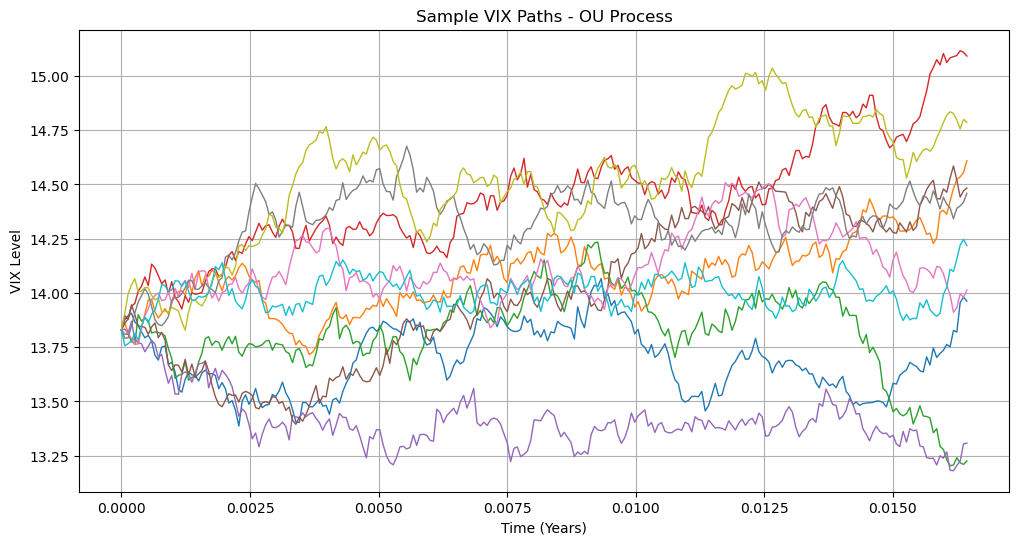

In [78]:
# Simulation parameters
spot_vix = inputs["spot_vix"]
T = inputs["time_to_maturity"]
r = inputs["risk_free_rate"]
num_paths = inputs["num_paths"]
num_steps = inputs["num_steps"]

dt = T / num_steps

# OU parameters
theta = 3.0   # mean-reversion speed
mu = 20.0     # long-run mean
sigma = 5.0   # volatility

# Initialize array for simulated paths
vix_paths = np.zeros((num_paths, num_steps + 1))
vix_paths[:, 0] = spot_vix

# Simulate VIX paths
for t in range(1, num_steps + 1):
    dW = np.random.normal(0, np.sqrt(dt), size=num_paths)
    vix_paths[:, t] = vix_paths[:, t-1] + theta * (mu - vix_paths[:, t-1]) * dt + sigma * dW

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.plot(np.linspace(0, T, num_steps + 1), vix_paths[i], lw=1)
plt.title("Sample VIX Paths - OU Process")
plt.xlabel("Time (Years)")
plt.ylabel("VIX Level")
plt.grid(True)
plt.show()

In [79]:
# Extract variables
r = inputs["risk_free_rate"]
T = inputs["time_to_maturity"]
num_paths = inputs["num_paths"]
strike_list = inputs["strikes"]

mid_price_list = inputs["mid_prices"]

# Use the strike corresponding to the median/mid option
strike_index = len(strike_list) // 2
strike_price = strike_list[strike_index]

# Extract the terminal VIX values
V_T = vix_paths[:, -1]

# Compute discounted payoff
call_payoffs = np.maximum(V_T - strike_price, 0)
monte_carlo_price = np.exp(-r * T) * np.mean(call_payoffs)

print(f"Monte Carlo Estimated Call Price: {monte_carlo_price:.4f}")

Monte Carlo Estimated Call Price: 0.1782


In [80]:
# Extract terminal VIX values from simulated paths
V_T = vix_paths[:, -1]

# Price a call option for each strike
call_prices = []
for strike in inputs["strikes"]:
    payoffs = np.maximum(V_T - strike, 0)
    price = np.exp(-r * T) * np.mean(payoffs)
    call_prices.append(price)

# Combine strikes and their corresponding prices into a dictionary or array
strike_call_pairs = list(zip(inputs["strikes"], call_prices))

# Convert to a DataFrame for better display and plotting
call_curve_df = pd.DataFrame(strike_call_pairs, columns=["Strike", "Call Price"])

call_curve_df.head()

,Strike,Call Price
0,9.68,4.447994
1,10.60,3.528795
2,11.52,2.609597
3,12.45,1.681073
4,13.37,0.795442


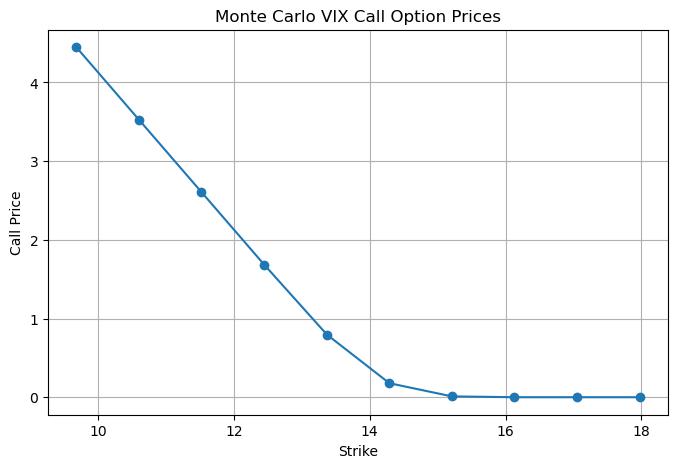

In [81]:
plt.figure(figsize=(8, 5))
plt.plot(call_curve_df["Strike"], call_curve_df["Call Price"], marker='o')
plt.title("Monte Carlo VIX Call Option Prices")
plt.xlabel("Strike")
plt.ylabel("Call Price")
plt.grid(True)
plt.show()

In [82]:
# Price a put option for each strike
put_prices = []
for strike in inputs["strikes"]:
    payoffs = np.maximum(strike - V_T, 0)
    price = np.exp(-r * T) * np.mean(payoffs)
    put_prices.append(price)

# Combine strikes and their corresponding put prices
strike_put_pairs = list(zip(inputs["strikes"], put_prices))

# Create DataFrame
put_curve_df = pd.DataFrame(strike_put_pairs, columns=["Strike", "Put Price"])

put_curve_df.head()

,Strike,Put Price
0,9.68,0.000000
1,10.60,0.000000
2,11.52,0.000000
3,12.45,0.000667
4,13.37,0.034234


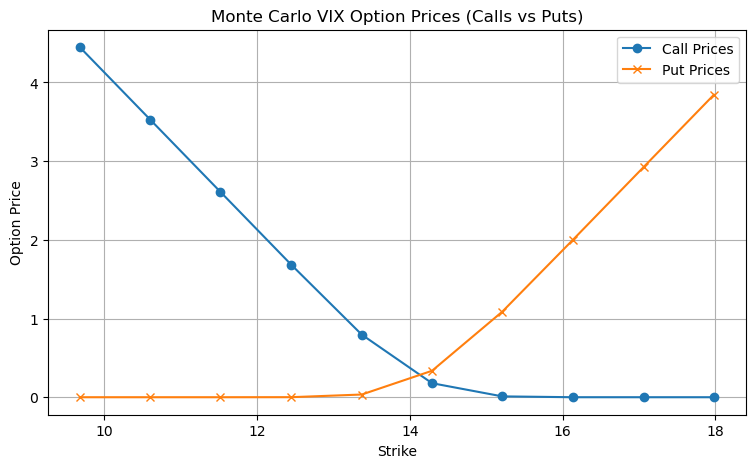

In [83]:
plt.figure(figsize=(9, 5))
plt.plot(call_curve_df["Strike"], call_curve_df["Call Price"], label="Call Prices", marker='o')
plt.plot(put_curve_df["Strike"], put_curve_df["Put Price"], label="Put Prices", marker='x')
plt.title("Monte Carlo VIX Option Prices (Calls vs Puts)")
plt.xlabel("Strike")
plt.ylabel("Option Price")
plt.legend()
plt.grid(True)
plt.show()

## 5. Implied Volatility Extraction

Implied volatilities are computed by inverting the Black–Scholes formula using the Monte Carlo option prices.

In [84]:
# Extract inputs
r = inputs["risk_free_rate"]
T = float(inputs["time_to_maturity"])
strikes = np.array(inputs["strikes"])
spot = float(inputs["spot_vix"])

# Use previously simulated call and put prices
call_prices = call_curve_df["Call Price"].values
put_prices = put_curve_df["Put Price"].values

# -------------------------------
# 1. Black-Scholes Option Pricing
# -------------------------------
def black_scholes_price(S, K, T, r, sigma, option_type="call"):
    if T <= 0 or sigma <= 0:
        return max(S - K, 0) if option_type == "call" else max(K - S, 0)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == "put":
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

# ------------------------------------
# 2. Invert Black-Scholes (Find IVs)
# ------------------------------------
def implied_volatility(price, S, K, T, r, option_type):
    try:
        # Define objective function
        f = lambda sigma: black_scholes_price(S, K, T, r, sigma, option_type) - price

        # Solve for root using Brent’s method
        return brentq(f, 1e-6, 5.0, maxiter=500)
    except ValueError:
        return np.nan

# -----------------------------------------
# 3. Estimate IVs for Calls and Puts
# -----------------------------------------
call_ivs = [implied_volatility(p, spot, K, T, r, "call") for p, K in zip(call_prices, strikes)]
put_ivs  = [implied_volatility(p, spot, K, T, r, "put") for p, K in zip(put_prices, strikes)]

# -----------------------------------------
# 4. Create DataFrame with Results
# -----------------------------------------
iv_df = pd.DataFrame({
    "Strike": strikes,
    "Call IV": call_ivs,
    "Put IV": put_ivs
})

iv_df.head()

,Strike,Call IV,Put IV
0,9.68,2.639372,0.000001
1,10.60,2.139707,0.000001
2,11.52,1.664449,0.000001
3,12.45,1.194182,0.312582
4,13.37,0.757338,0.258351


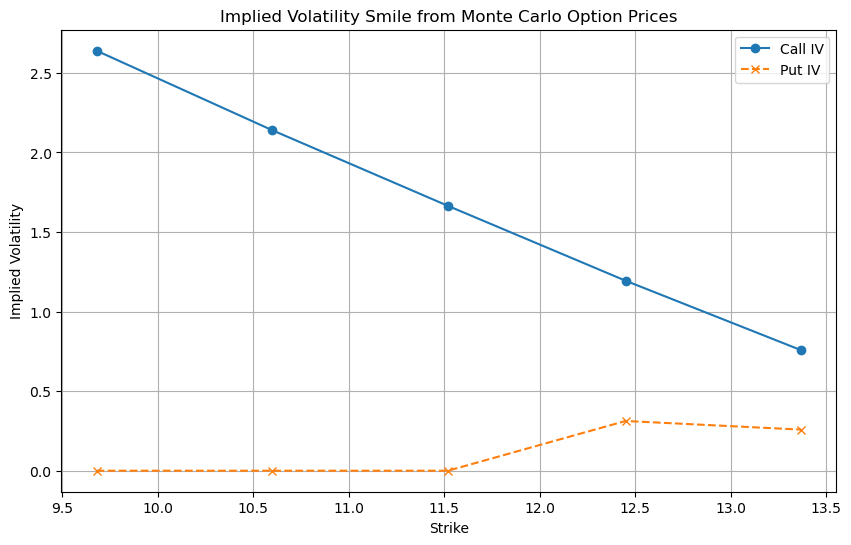

In [85]:
iv_df_clean = iv_df.dropna()

plt.figure(figsize=(10, 6))
plt.plot(iv_df_clean["Strike"], iv_df_clean["Call IV"], label="Call IV", marker='o')
plt.plot(iv_df_clean["Strike"], iv_df_clean["Put IV"], label="Put IV", marker='x', linestyle='--')

plt.title("Implied Volatility Smile from Monte Carlo Option Prices")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.legend()
plt.grid(True)
plt.show()

## 6. Stochastic Volatility Extension

The model is extended to include stochastic volatility dynamics for VIX, introducing a correlated variance process.

In [86]:
# Simulation parameters
T = inputs["time_to_maturity"]
r = inputs["risk_free_rate"]
spot = inputs["spot_vix"]
num_paths = inputs["num_paths"]
num_steps = inputs["num_steps"]
dt = T / num_steps

# Model parameters
kappa = 2.0         # speed of mean reversion of VIX
theta = spot        # long-term mean of VIX
rho = -0.5          # correlation between VIX and its vol
alpha = 1.5         # speed of mean reversion of vol-of-vol
nu_bar = 0.04       # long-term variance
sigma_nu = 0.3      # vol of vol-of-vol
v0 = spot           # initial VIX
nu0 = 0.04          # initial variance of VIX

# Arrays for simulation
V = np.zeros((num_paths, num_steps + 1))
nu = np.zeros((num_paths, num_steps + 1))
V[:, 0] = v0
nu[:, 0] = nu0

# Generate correlated random numbers
Z1 = np.random.normal(size=(num_paths, num_steps))
Z2 = rho * Z1 + np.sqrt(1 - rho**2) * np.random.normal(size=(num_paths, num_steps))

# Simulate paths
for t in range(1, num_steps + 1):
    nu[:, t] = np.abs(nu[:, t - 1] + alpha * (nu_bar - nu[:, t - 1]) * dt +
                      sigma_nu * np.sqrt(nu[:, t - 1]) * np.sqrt(dt) * Z2[:, t - 1])
    
    V[:, t] = V[:, t - 1] + kappa * (theta - V[:, t - 1]) * dt + \
              np.sqrt(nu[:, t - 1]) * np.sqrt(dt) * Z1[:, t - 1]

vix_paths_stochvol = V

## 7. Calibration of OU Model Parameters

The Ornstein–Uhlenbeck parameters are estimated from historical log-VIX data via maximum likelihood.

Estimated OU parameters:
  κ (mean reversion): 10.2554
  θ (long-term mean): 2.9563
  σ (vol of vol): 1.1844


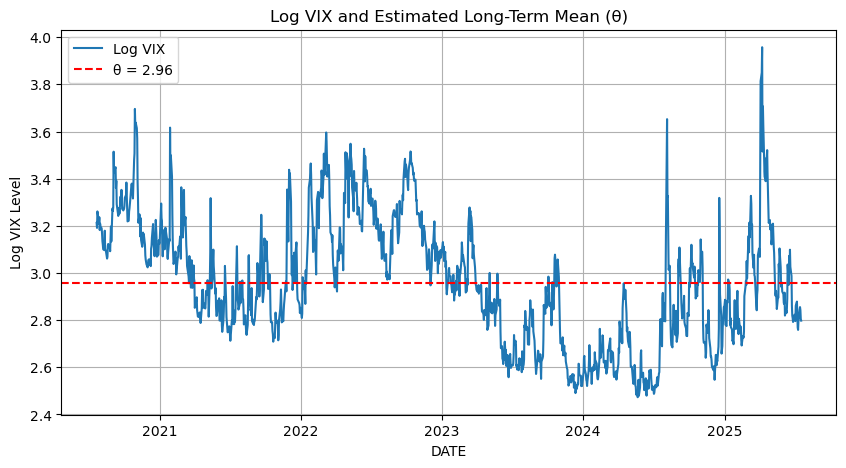

In [87]:
# Load historical VIX data
vix_df = pd.read_csv("data/raw/VIXCLS.csv")
vix_df.dropna(inplace=True)

# Parse dates and sort
vix_df['observation_date'] = pd.to_datetime(vix_df['observation_date'])
vix_df.sort_values('observation_date', inplace=True)
vix_df.reset_index(drop=True, inplace=True)

# Log transform to stabilize variance
vix_df['log_vix'] = np.log(vix_df['VIXCLS'])

# Calculate daily log returns
vix_df['log_return'] = vix_df['log_vix'].diff()
vix_df['lag_log_vix'] = vix_df['log_vix'].shift(1)

# Drop NaNs from diff/shift
vix_df.dropna(inplace=True)

# Define OU log-likelihood function
def ou_neg_log_likelihood(params, x, dt=1/252):
    kappa, theta, sigma = params
    drift = kappa * (theta - x[:-1]) * dt
    diffusion = sigma * np.sqrt(dt)
    residuals = (x[1:] - x[:-1] - drift) / diffusion
    nll = 0.5 * np.sum(residuals**2 + np.log(2 * np.pi * diffusion**2))
    return nll

# Initial guess
x = vix_df['log_vix'].values
initial_params = [5.0, np.mean(x), 0.1]

# Optimize
result = minimize(ou_neg_log_likelihood, initial_params, args=(x,), bounds=[(1e-6, None)]*3)

# Extract estimated parameters
kappa, theta, sigma = result.x
print(f"Estimated OU parameters:\n  κ (mean reversion): {kappa:.4f}\n  θ (long-term mean): {theta:.4f}\n  σ (vol of vol): {sigma:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(vix_df['observation_date'], vix_df['log_vix'], label='Log VIX')
plt.axhline(theta, color='red', linestyle='--', label=f'θ = {theta:.2f}')
plt.title("Log VIX and Estimated Long-Term Mean (θ)")
plt.xlabel("DATE")
plt.ylabel("Log VIX Level")
plt.legend()
plt.grid(True)
plt.show()

## 8. Simulating VIX Paths Using Calibrated Parameters

Using the estimated OU parameters, VIX paths are simulated to visualize the dynamics implied by the calibrated model.

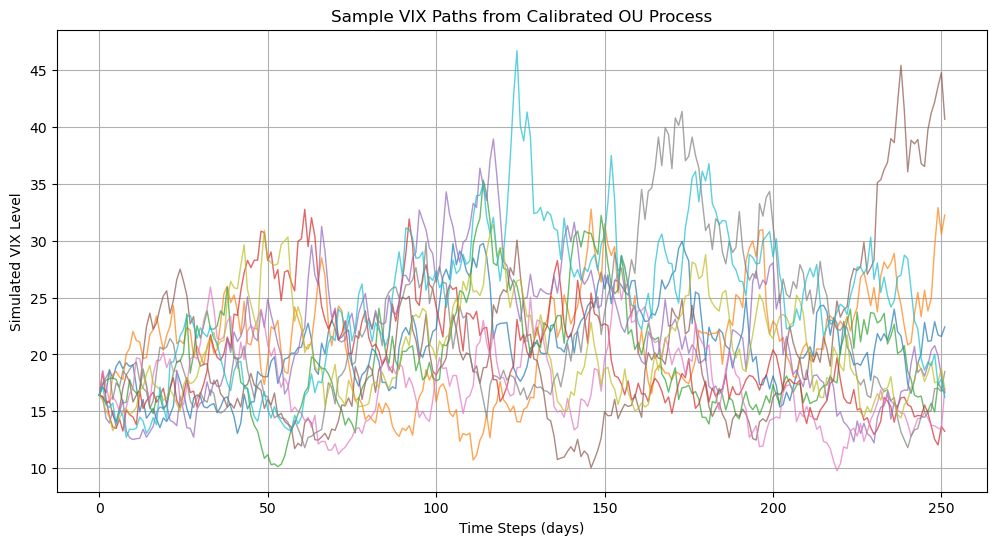

In [101]:
# Simulate OU process using estimated parameters
np.random.seed(42)

# Parameters
dt = 1/252
T = 1  # 1 year
n_steps = int(T / dt)
n_paths = 10
V0 = vix_df['log_vix'].iloc[-1]

# Extract estimated OU parameters
kappa = 10.2553
theta = 2.9563
sigma = 1.1844

# Initialize path array
ou_paths = np.zeros((n_paths, n_steps))
ou_paths[:, 0] = V0

# Simulate using Euler scheme
for t in range(1, n_steps):
    dW = np.random.randn(n_paths) * np.sqrt(dt)
    ou_paths[:, t] = ou_paths[:, t-1] + kappa * (theta - ou_paths[:, t-1]) * dt + sigma * dW

# Convert back to VIX levels
vix_paths_simulated = np.exp(ou_paths)

plt.figure(figsize=(12, 6))
for i in range(n_paths):
    plt.plot(vix_paths_simulated[i], lw=1, alpha=0.7)

plt.title("Sample VIX Paths from Calibrated OU Process")
plt.xlabel("Time Steps (days)")
plt.ylabel("Simulated VIX Level")
plt.grid(True)
plt.show()

In [89]:
# Reuse OU parameters
kappa = 10.2553
theta = 2.9563
sigma = 1.1844
spot_vix = inputs["spot_vix"]
T = inputs["time_to_maturity"]
n_steps = inputs["num_steps"]
dt = T / n_steps
n_paths = inputs["num_paths"]

# Simulate log-VIX using Euler-Maruyama scheme
np.random.seed(42)
log_vix_paths = np.zeros((n_paths, n_steps + 1))
log_vix_paths[:, 0] = np.log(spot_vix)

for t in range(1, n_steps + 1):
    dW = np.random.randn(n_paths) * np.sqrt(dt)
    log_vix_paths[:, t] = log_vix_paths[:, t - 1] + \
        kappa * (theta - log_vix_paths[:, t - 1]) * dt + sigma * dW

# Convert to VIX levels
vix_paths = np.exp(log_vix_paths)
V_T = vix_paths[:, -1]

# Price call and put options
call_prices = []
put_prices = []
for strike in inputs["strikes"]:
    call_payoff = np.maximum(V_T - strike, 0)
    put_payoff = np.maximum(strike - V_T, 0)
    discount = np.exp(-inputs["risk_free_rate"] * T)

    call_price = discount * np.mean(call_payoff)
    put_price = discount * np.mean(put_payoff)

    call_prices.append(call_price)
    put_prices.append(put_price)

# Store in dataframe for visualization
strike_prices = inputs["strikes"]
option_df = pd.DataFrame({
    "Strike": strike_prices,
    "Call (OU)": call_prices,
    "Put (OU)": put_prices 
})

option_df.head()

,Strike,Call (OU),Put (OU)
0,9.68,5.000655,0.000428
1,10.60,4.086723,0.005695
2,11.52,3.191952,0.030122
3,12.45,2.343724,0.111084
4,13.37,1.608989,0.295548


## 9. Pricing Diagnostics vs Market

Monte Carlo option prices are compared with observed market mid prices to evaluate model fit and identify pricing errors across strikes.

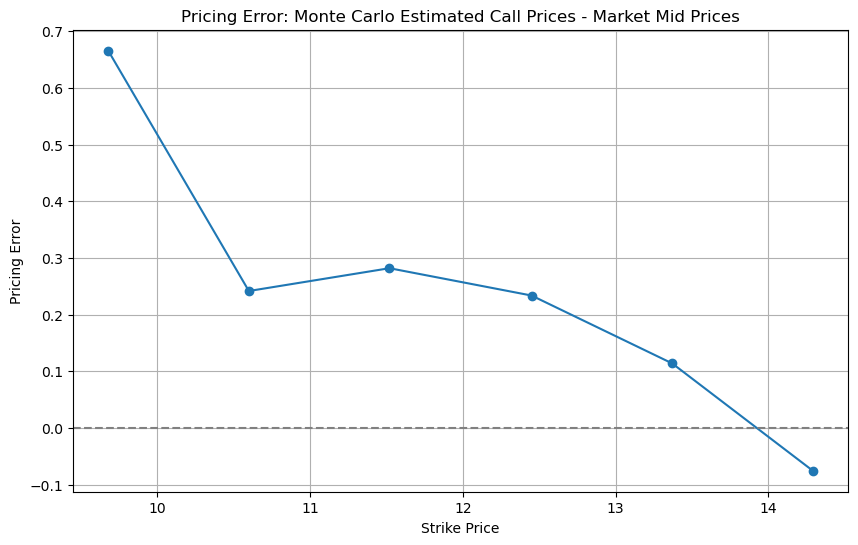

In [90]:
strikes = np.array(inputs["strikes"])
mid_prices = np.array(inputs["mid_prices"])
estimated_call_prices = np.array(call_prices[:len(mid_prices)])

# Compute errors
pricing_errors = estimated_call_prices - mid_prices

plt.figure(figsize=(10, 6))
plt.plot(strikes[:len(mid_prices)], pricing_errors, marker='o', linestyle='-')
plt.axhline(0, color='gray', linestyle='--')
plt.title("Pricing Error: Monte Carlo Estimated Call Prices - Market Mid Prices")
plt.xlabel("Strike Price")
plt.ylabel("Pricing Error")
plt.grid(True)
plt.show()

## 10. Option Greeks via Finite Differences

Option Greeks (Delta, Gamma, Vega, Theta, and Rho) are estimated using finite-difference methods applied to the Monte Carlo pricing model.

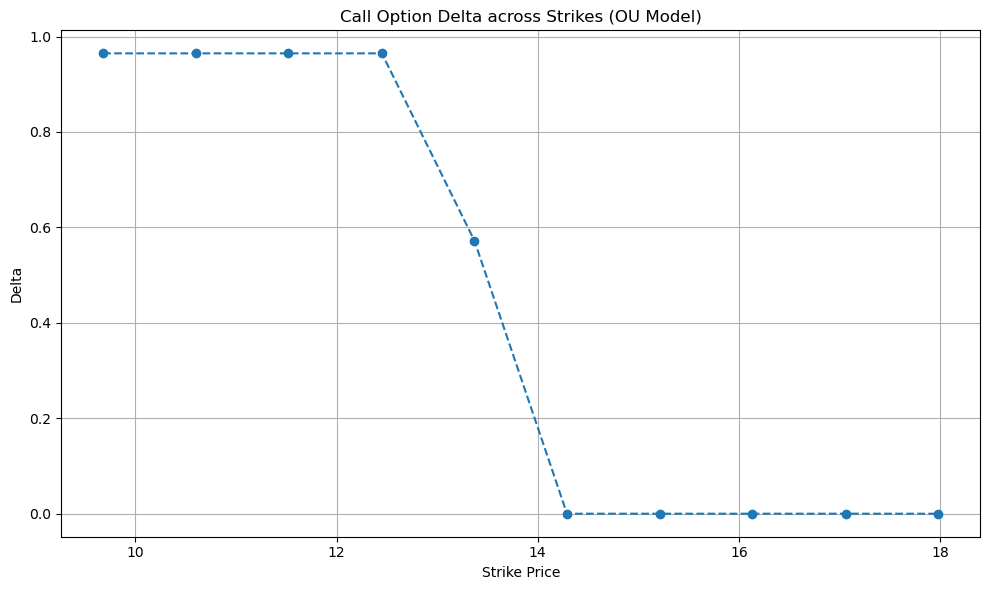

In [91]:
# Extract parameters
spot = inputs["spot_vix"]
strikes = np.array(inputs["strikes"])
rate = inputs["risk_free_rate"]
tau = inputs["time_to_maturity"]
kappa = 2.0
theta = 0.25
sigma = 0.5
n_paths = 10000
n_steps = 100

# Monte Carlo simulation for OU model
def simulate_vix_paths(spot, kappa, theta, sigma, tau, n_paths, n_steps):
    dt = tau / n_steps
    paths = np.zeros((n_paths, n_steps + 1))
    paths[:, 0] = spot
    for t in range(1, n_steps + 1):
        dz = np.random.normal(0, np.sqrt(dt), size=n_paths)
        paths[:, t] = paths[:, t-1] + kappa * (theta - paths[:, t-1]) * dt + sigma * dz
    return paths

# Option pricing via Monte Carlo
def monte_carlo_option_price(spot, strikes, kappa, theta, sigma, tau, rate, option_type="call", bump=0.0):
    bumped_spot = spot + bump
    paths = simulate_vix_paths(bumped_spot, kappa, theta, sigma, tau, n_paths, n_steps)
    vix_T = paths[:, -1]
    prices = []
    for K in strikes:
        if option_type == "call":
            payoff = np.maximum(vix_T - K, 0)
        else:
            payoff = np.maximum(K - vix_T, 0)
        price = np.exp(-rate * tau) * np.mean(payoff)
        prices.append(price)
    return np.array(prices)

# Compute Delta via finite difference
epsilon = 0.1
call_prices_up = monte_carlo_option_price(spot, strikes, kappa, theta, sigma, tau, rate, "call", bump=epsilon)
call_prices_down = monte_carlo_option_price(spot, strikes, kappa, theta, sigma, tau, rate, "call", bump=-epsilon)
delta = (call_prices_up - call_prices_down) / (2 * epsilon)

plt.figure(figsize=(10, 6))
plt.plot(strikes, delta, marker='o', linestyle='--')
plt.title('Call Option Delta across Strikes (OU Model)')
plt.xlabel('Strike Price')
plt.ylabel('Delta')
plt.grid(True)
plt.tight_layout()
plt.show()

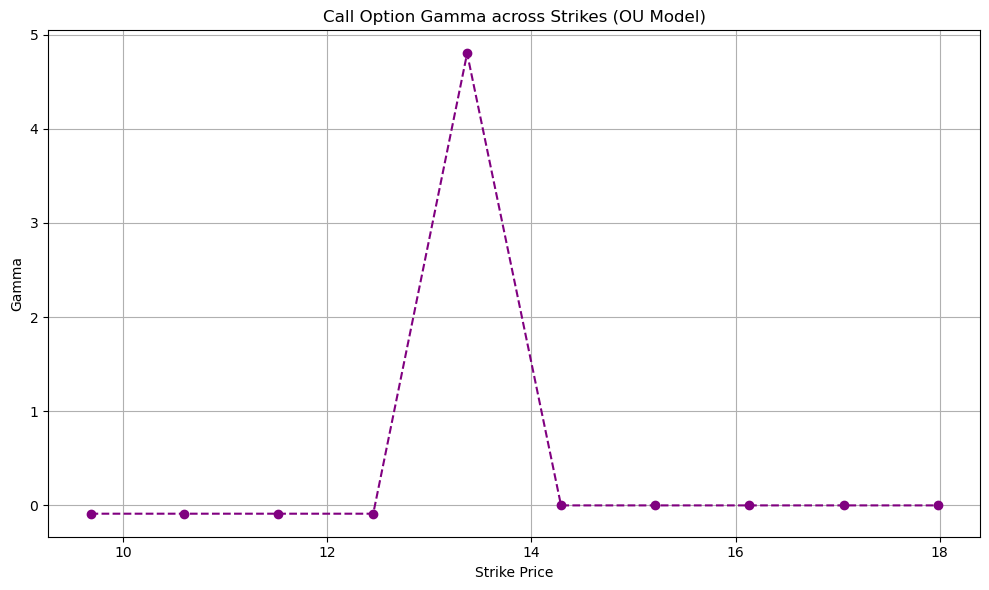

In [92]:
# Extract parameters
spot = inputs["spot_vix"]
strikes = np.array(inputs["strikes"])
rate = inputs["risk_free_rate"]
tau = inputs["time_to_maturity"]
kappa = inputs["kappa"]
theta = inputs["theta"]
sigma = inputs["sigma"]
n_paths = 10000
n_steps = 100

# Monte Carlo simulation function
def simulate_vix_paths(spot, kappa, theta, sigma, tau, n_paths, n_steps):
    dt = tau / n_steps
    paths = np.zeros((n_paths, n_steps + 1))
    paths[:, 0] = spot
    for t in range(1, n_steps + 1):
        dz = np.random.normal(0, np.sqrt(dt), size=n_paths)
        paths[:, t] = paths[:, t-1] + kappa * (theta - paths[:, t-1]) * dt + sigma * dz
    return paths

# Option pricing via Monte Carlo
def monte_carlo_option_price(spot, strikes, kappa, theta, sigma, tau, rate, option_type="call", bump=0.0):
    bumped_spot = spot + bump
    paths = simulate_vix_paths(bumped_spot, kappa, theta, sigma, tau, n_paths, n_steps)
    vix_T = paths[:, -1]
    prices = []
    for K in strikes:
        if option_type == "call":
            payoff = np.maximum(vix_T - K, 0)
        else:
            payoff = np.maximum(K - vix_T, 0)
        price = np.exp(-rate * tau) * np.mean(payoff)
        prices.append(price)
    return np.array(prices)

# Compute Gamma using finite difference
epsilon = 0.1
call_prices_up = monte_carlo_option_price(spot, strikes, kappa, theta, sigma, tau, rate, "call", bump=epsilon)
call_prices_down = monte_carlo_option_price(spot, strikes, kappa, theta, sigma, tau, rate, "call", bump=-epsilon)
call_prices_base = monte_carlo_option_price(spot, strikes, kappa, theta, sigma, tau, rate, "call", bump=0.0)

gamma = (call_prices_up - 2 * call_prices_base + call_prices_down) / (epsilon ** 2)

plt.figure(figsize=(10, 6))
plt.plot(strikes, gamma, marker='o', linestyle='--', color='purple')
plt.title('Call Option Gamma across Strikes (OU Model)')
plt.xlabel('Strike Price')
plt.ylabel('Gamma')
plt.grid(True)
plt.tight_layout()
plt.show()

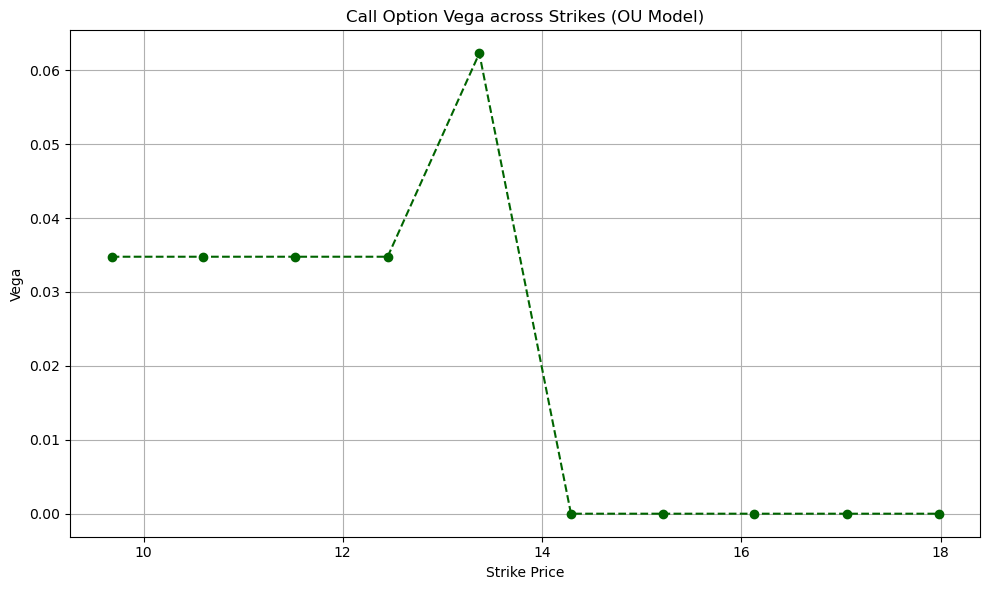

In [93]:
# Extract necessary parameters
spot = inputs["spot_vix"]
strikes = np.array(inputs["strikes"])
rate = inputs["risk_free_rate"]
tau = inputs["time_to_maturity"]
kappa = inputs["kappa"]
theta = inputs["theta"]
sigma = inputs["sigma"]
n_paths = inputs["num_paths"]
n_steps = inputs["num_steps"]

# Monte Carlo simulation for VIX paths
def simulate_vix_paths(spot, kappa, theta, sigma, tau, n_paths, n_steps):
    dt = tau / n_steps
    paths = np.zeros((n_paths, n_steps + 1))
    paths[:, 0] = spot
    for t in range(1, n_steps + 1):
        dz = np.random.normal(0, np.sqrt(dt), size=n_paths)
        paths[:, t] = paths[:, t-1] + kappa * (theta - paths[:, t-1]) * dt + sigma * dz
    return paths

# Option pricing via Monte Carlo
def monte_carlo_option_price(spot, strikes, kappa, theta, sigma, tau, rate, option_type="call"):
    paths = simulate_vix_paths(spot, kappa, theta, sigma, tau, n_paths, n_steps)
    vix_T = paths[:, -1]
    prices = []
    for K in strikes:
        if option_type == "call":
            payoff = np.maximum(vix_T - K, 0)
        else:
            payoff = np.maximum(K - vix_T, 0)
        price = np.exp(-rate * tau) * np.mean(payoff)
        prices.append(price)
    return np.array(prices)

# Compute Vega using finite difference method
epsilon = 0.01
prices_up = monte_carlo_option_price(spot, strikes, kappa, theta, sigma + epsilon, tau, rate)
prices_down = monte_carlo_option_price(spot, strikes, kappa, theta, sigma - epsilon, tau, rate)
vega = (prices_up - prices_down) / (2 * epsilon)

plt.figure(figsize=(10, 6))
plt.plot(strikes, vega, marker='o', linestyle='--', color='darkgreen')
plt.title('Call Option Vega across Strikes (OU Model)')
plt.xlabel('Strike Price')
plt.ylabel('Vega')
plt.grid(True)
plt.tight_layout()
plt.show()

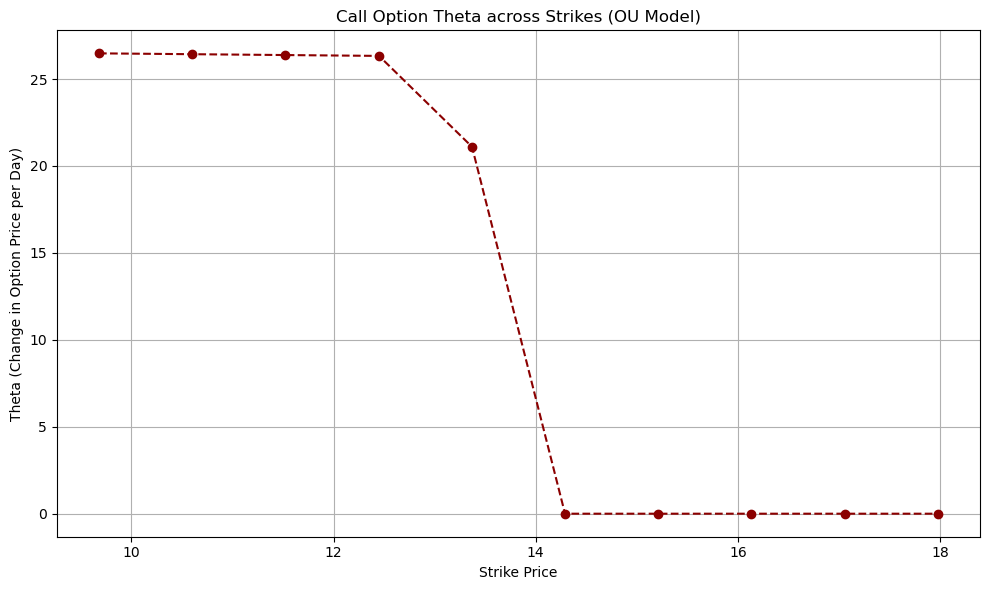

In [94]:
# Extract parameters
spot = inputs["spot_vix"]
strikes = np.array(inputs["strikes"])
rate = inputs["risk_free_rate"]
tau = inputs["time_to_maturity"]
kappa = inputs["kappa"]
theta_ou = inputs["theta"]
sigma = inputs["sigma"]
n_paths = inputs["num_paths"]
n_steps = inputs["num_steps"]

# OU path simulation
def simulate_vix_paths(spot, kappa, theta, sigma, tau, n_paths, n_steps):
    dt = tau / n_steps
    paths = np.zeros((n_paths, n_steps + 1))
    paths[:, 0] = spot
    for t in range(1, n_steps + 1):
        dz = np.random.normal(0, np.sqrt(dt), size=n_paths)
        paths[:, t] = paths[:, t-1] + kappa * (theta - paths[:, t-1]) * dt + sigma * dz
    return paths

# Monte Carlo pricing function
def monte_carlo_option_price(spot, strikes, kappa, theta, sigma, tau, rate, option_type="call"):
    paths = simulate_vix_paths(spot, kappa, theta, sigma, tau, n_paths, n_steps)
    vix_T = paths[:, -1]
    prices = []
    for K in strikes:
        if option_type == "call":
            payoff = np.maximum(vix_T - K, 0)
        else:
            payoff = np.maximum(K - vix_T, 0)
        price = np.exp(-rate * tau) * np.mean(payoff)
        prices.append(price)
    return np.array(prices)

# Finite difference
epsilon_tau = 1 / 365  # One day
call_prices_now = monte_carlo_option_price(spot, strikes, kappa, theta_ou, sigma, tau, rate, "call")
call_prices_shorter_tau = monte_carlo_option_price(spot, strikes, kappa, theta_ou, sigma, tau - epsilon_tau, rate, "call")

# Theta approximation
theta = (call_prices_shorter_tau - call_prices_now) / epsilon_tau

plt.figure(figsize=(10, 6))
plt.plot(strikes, theta, marker='o', linestyle='--', color='darkred')
plt.title('Call Option Theta across Strikes (OU Model)')
plt.xlabel('Strike Price')
plt.ylabel('Theta (Change in Option Price per Day)')
plt.grid(True)
plt.tight_layout()
plt.show()

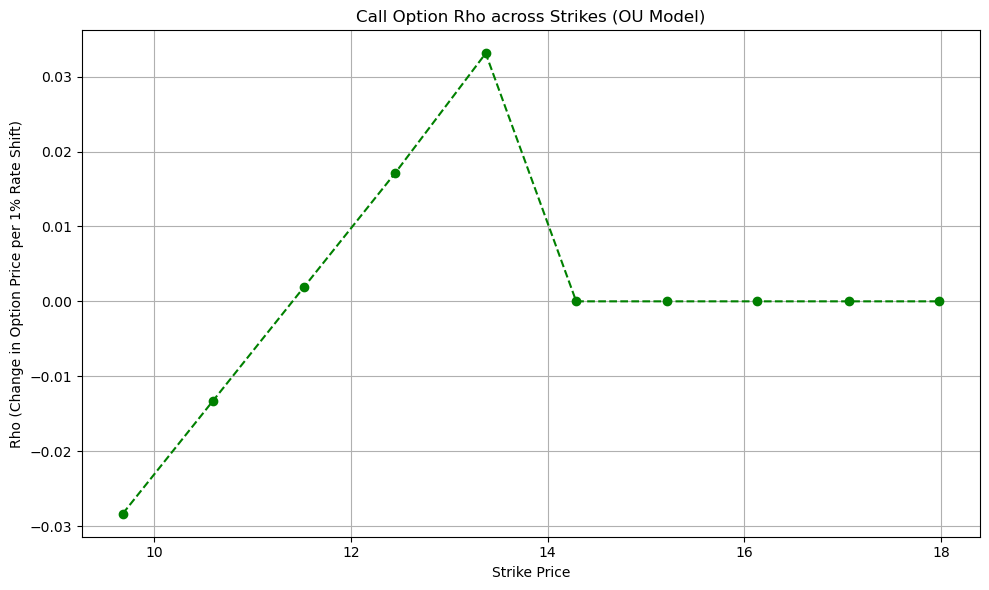

In [95]:
# Extract parameters
spot = inputs["spot_vix"]
strikes = np.array(inputs["strikes"])
rate = inputs["risk_free_rate"]
tau = inputs["time_to_maturity"]
kappa = inputs["kappa"]
theta_ou = inputs["theta"]
sigma = inputs["sigma"]
n_paths = inputs["num_paths"]
n_steps = inputs["num_steps"]

# OU path simulation
def simulate_vix_paths(spot, kappa, theta, sigma, tau, n_paths, n_steps):
    dt = tau / n_steps
    paths = np.zeros((n_paths, n_steps + 1))
    paths[:, 0] = spot
    for t in range(1, n_steps + 1):
        dz = np.random.normal(0, np.sqrt(dt), size=n_paths)
        paths[:, t] = paths[:, t-1] + kappa * (theta - paths[:, t-1]) * dt + sigma * dz
    return paths

# Pricing function
def monte_carlo_option_price(spot, strikes, kappa, theta, sigma, tau, rate, option_type="call"):
    paths = simulate_vix_paths(spot, kappa, theta, sigma, tau, n_paths, n_steps)
    vix_T = paths[:, -1]
    prices = []
    for K in strikes:
        if option_type == "call":
            payoff = np.maximum(vix_T - K, 0)
        else:
            payoff = np.maximum(K - vix_T, 0)
        price = np.exp(-rate * tau) * np.mean(payoff)
        prices.append(price)
    return np.array(prices)

# Finite difference approximation for Rho
epsilon_r = 0.01  # 1% rate shift
call_prices_up = monte_carlo_option_price(spot, strikes, kappa, theta_ou, sigma, tau, rate + epsilon_r, "call")
call_prices_down = monte_carlo_option_price(spot, strikes, kappa, theta_ou, sigma, tau, rate - epsilon_r, "call")
rho = (call_prices_up - call_prices_down) / (2 * epsilon_r)

plt.figure(figsize=(10, 6))
plt.plot(strikes, rho, marker='o', linestyle='--', color='green')
plt.title('Call Option Rho across Strikes (OU Model)')
plt.xlabel('Strike Price')
plt.ylabel('Rho (Change in Option Price per 1% Rate Shift)')
plt.grid(True)
plt.tight_layout()
plt.show()